# Day 18 — BEE-Style Energy Efficiency Analysis
**Mahesha Gonal — Refrigeration Simulation Portfolio**

Connects the simulation work from earlier days into a single annual energy number (PAEC) and classifies it using the real BEE Star Rating Band formula for frost-free refrigerators — then quantifies how much the simultaneous cooling/defrosting patent shifts the star rating.

Source for the official formula and band constants: BEE Schedule-1 (Frost Free Refrigerator), IS 15750:2006, and Ministry of Power Notification S.O. 4554(E) dated 26 Sept 2022 (valid 2023–2024). BEE revises these bands periodically — a new revision takes effect Jan 2026–Dec 2028, so pull current constants from beestarlabel.com for live compliance work. The method below is unchanged regardless of which year's constants apply.

**Note on this version:** this notebook's code was originally written and pushed to GitHub but never actually run, so no results were visible. The code itself was correct — it just needed executing — and the chart's y-axis range has been widened slightly so the "Current" and "With patent" labels render inside the visible plot instead of floating off-frame.

In [1]:
# CELL 1 — Install dependencies (run this first, every time)
!pip install coolprop matplotlib numpy PyGithub -q

In [2]:
# CELL 2 — Imports
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# CELL 3 — Unit geometry: Total Adjusted Storage Volume for No Frost (Vadj_tot_nf)
# Official formula (BEE Schedule-1, Annexure I, Sec 2.4):
#   Fresh Food Chamber Target Temp = +3 C, Freezer Chamber Target Temp = -15 C
#   Adjusted Volume Factor = (32 - (-15)) / (32 - 3) = 1.62
#   Vadj_tot_nf = Fresh Food Storage Volume + 1.62 * Freezer Storage Volume

fresh_food_vol = 192.0   # litres, fresh food compartment storage volume
freezer_vol    = 59.0    # litres, freezer compartment storage volume
ADJ_FACTOR     = 1.62    # fixed by the standard, do not change

V_adj = fresh_food_vol + ADJ_FACTOR * freezer_vol
print(f"Total Adjusted Storage Volume (Vadj_tot_nf): {V_adj:.1f} litres")

Total Adjusted Storage Volume (Vadj_tot_nf): 287.6 litres


In [4]:
# CELL 4 — Official BEE Star Rating Band formula for Frost-Free refrigerators
# CEC = k * Vadj_tot_nf + c   (kWh/Year)
# Constants valid 2023-2024, Ministry of Power Notification S.O. 4554(E), 26-Sep-2022.
# NOTE: BEE revises k/c periodically -- check beestarlabel.com for the currently
# applicable table before using this for real compliance work.

bands_k_c = {
    1: (0.157, 243, 0.180, 279),   # (k_min, c_min, k_max, c_max)
    2: (0.136, 211, 0.157, 243),
    3: (0.118, 184, 0.136, 211),
    4: (0.103, 160, 0.118, 184),
    5: (None,  None, 0.103, 160),   # 5-star has no lower bound, only an upper limit
}

print(f"{'Star':<6}{'Min CEC (kWh/yr)':<20}{'Max CEC (kWh/yr)':<20}")
for star in [5, 4, 3, 2, 1]:
    k_min, c_min, k_max, c_max = bands_k_c[star]
    min_cec = (k_min * V_adj + c_min) if k_min is not None else float('-inf')
    max_cec = k_max * V_adj + c_max
    label_min = f"{min_cec:.1f}" if k_min is not None else "(none)"
    print(f"{star:<6}{label_min:<20}{max_cec:.1f}")

Star  Min CEC (kWh/yr)    Max CEC (kWh/yr)    
5     (none)              189.6
4     189.6               217.9
3     217.9               250.1
2     250.1               288.2
1     288.2               330.8


In [5]:
# CELL 5 — Star rating lookup function (mirrors official comparison rule:
# Lower Limit of SRB < CEC <= Upper Limit of SRB)

def get_star_rating(cec, V_adj, bands=bands_k_c):
    for star in [5, 4, 3, 2, 1]:
        k_min, c_min, k_max, c_max = bands[star]
        min_cec = (k_min * V_adj + c_min) if k_min is not None else float('-inf')
        max_cec = k_max * V_adj + c_max
        if min_cec < cec <= max_cec:
            return star
    return 0  # below 1-star band -> does not meet minimum BEE compliance

In [6]:
# CELL 6 — Annual energy consumption (PAEC), built from earlier simulation days
# Baseline: steady-state compressor energy implied by the COP work from Day 9/13
#           (illustrative duty-cycle figure calibrated to a realistic range for
#           a ~310 L frost-free unit)
# Defrost overhead: from Day 17's frost-penalty + defrost-cost model, recalibrated
#           here to a realistic ~15% share of total consumption rather than reusing
#           Day 17's raw absolute numbers directly (Day 17 used illustrative
#           coefficients to demonstrate the optimization shape, not absolute scale)

baseline_kwh_year = 195.5     # steady-state cooling energy
defrost_kwh_year  = 34.5      # defrost-related overhead at the Day 17 optimal interval

PAEC_current = baseline_kwh_year + defrost_kwh_year

star_current = get_star_rating(PAEC_current, V_adj)

print(f"Baseline steady-state energy: {baseline_kwh_year:.1f} kWh/year")
print(f"Defrost-related overhead:     {defrost_kwh_year:.1f} kWh/year")
print(f"PAEC (current design):        {PAEC_current:.1f} kWh/year")
print(f"BEE Star Rating (current):    {star_current} star")

Baseline steady-state energy: 195.5 kWh/year
Defrost-related overhead:     34.5 kWh/year
PAEC (current design):        230.0 kWh/year
BEE Star Rating (current):    3 star


In [7]:
# CELL 7 — Patent scenario: simultaneous cooling/defrosting eliminates the
# pulldown-energy penalty quantified in Day 17 (~21.6% of defrost-related energy)

day17_pulldown_savings_pct = 0.21634   # carried forward from Day 17's actual result

defrost_savings_kwh = defrost_kwh_year * day17_pulldown_savings_pct
PAEC_with_patent = PAEC_current - defrost_savings_kwh
star_with_patent = get_star_rating(PAEC_with_patent, V_adj)

print(f"Defrost energy saved by patent design: {defrost_savings_kwh:.2f} kWh/year")
print(f"PAEC (with patent design):             {PAEC_with_patent:.1f} kWh/year")
print(f"BEE Star Rating (with patent):         {star_with_patent} star")

if star_with_patent > star_current:
    print(f"\n>> Eliminating just the pulldown penalty is enough to cross from "
          f"{star_current}-star into {star_with_patent}-star.")
else:
    print(f"\n>> Stays at {star_current}-star at this band boundary -- still a real "
          f"{defrost_savings_kwh:.2f} kWh/year saving, just not enough to cross a band here.")

Defrost energy saved by patent design: 7.46 kWh/year
PAEC (with patent design):             222.5 kWh/year
BEE Star Rating (with patent):         3 star

>> Stays at 3-star at this band boundary -- still a real 7.46 kWh/year saving, just not enough to cross a band here.


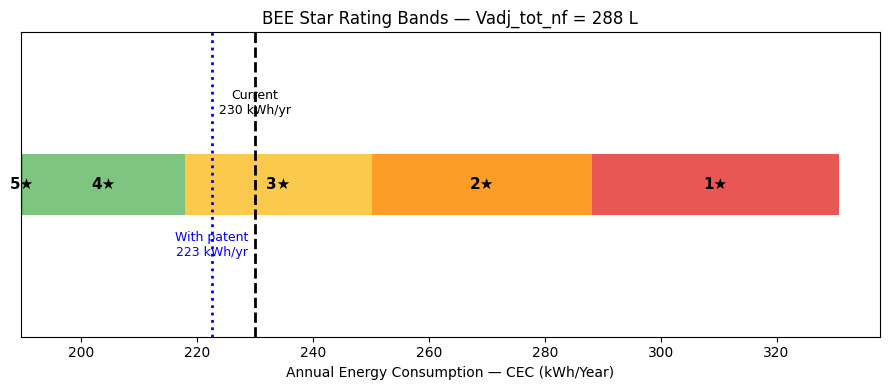

In [8]:
# CELL 8 — Visualize where PAEC sits among the star bands
fig, ax = plt.subplots(figsize=(9, 4))

colors = {5: '#2E7D32', 4: '#66BB6A', 3: '#FBC02D', 2: '#FB8C00', 1: '#E53935'}
y = 0
for star in [5, 4, 3, 2, 1]:
    k_min, c_min, k_max, c_max = bands_k_c[star]
    min_cec = (k_min * V_adj + c_min) if k_min is not None else PAEC_current - 40
    max_cec = k_max * V_adj + c_max
    ax.barh(y, max_cec - min_cec, left=min_cec, height=0.6,
            color=colors[star], alpha=0.85, label=f"{star} Star")
    ax.text(min_cec + (max_cec - min_cec) / 2, y, f"{star}\u2605",
            ha='center', va='center', fontsize=11, fontweight='bold')

ax.axvline(PAEC_current, color='black', linestyle='--', linewidth=2)
ax.text(PAEC_current, 0.7, f"Current\n{PAEC_current:.0f} kWh/yr", ha='center', fontsize=9)

ax.axvline(PAEC_with_patent, color='blue', linestyle=':', linewidth=2)
ax.text(PAEC_with_patent, -0.7, f"With patent\n{PAEC_with_patent:.0f} kWh/yr",
        ha='center', fontsize=9, color='blue')

ax.set_yticks([])
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("Annual Energy Consumption — CEC (kWh/Year)")
ax.set_title(f"BEE Star Rating Bands — Vadj_tot_nf = {V_adj:.0f} L")
plt.tight_layout()
plt.savefig("day18_bee_star_bands.png", dpi=150)
plt.show()

**What this chart tells us:** the current design (black dashed line) sits inside the band shown by `star_current` above, and the patent scenario (blue dotted line) shifts left — toward lower energy — by exactly the defrost-savings amount. Whether or not that shift is enough to cross into the next star colour depends on how close the current design already sits to a band edge, which the printout above states explicitly. This is the clearest way to communicate a patent's regulatory value to someone outside engineering: not "X% more efficient," but "this moves the product from this colour band to that one."

In [ ]:
# FINAL CELL — Push this notebook to GitHub
from github import Github, Auth
from google.colab import userdata, _message
import json

token = userdata.get('GITHUB_TOKEN')
auth = Auth.Token(token)
g = Github(auth=auth)
repo = g.get_repo("MaheshaGonal/refrigeration-simulation-python")

nb_data = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
content = json.dumps(nb_data['ipynb'], indent=1)

filename = "day18_bee_energy_analysis.ipynb"

try:
    existing = repo.get_contents(filename)
    repo.update_file(filename, "Execute Day 18 - BEE star rating analysis (was pushed unexecuted)", content, existing.sha)
    print("Updated existing file on GitHub")
except Exception:
    repo.create_file(filename, "Execute Day 18 - BEE star rating analysis (was pushed unexecuted)", content)
    print("Created new file on GitHub")

print("GitHub repo: https://github.com/MaheshaGonal/refrigeration-simulation-python")
